In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pynwb import TimeSeries
from pynwb import NWBHDF5IO
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import jax
os.chdir("..")

# Load Data

In [2]:
path = "/stelmo/sam/c3po_datasets/sub-Han_desc-train_behavior+ecephys.nwb"

# nwb file
os.path.exists(path)
io = NWBHDF5IO(path, "r")
nwbfile = io.read()

# behavior data
data = []
joint_data = []
muscle_data = []
for object in nwbfile.objects.values():
    if isinstance(object, TimeSeries):
        for id_ in ["hand"]:
            if id_ in object.name.lower() or id_ in object.description.lower():
                data.append(object)
        id_ = "joint"
        if id_ in object.name.lower() or id_ in object.description.lower():
            joint_data.append(object)
        id_ = "muscle"
        if id_ in object.name.lower() or id_ in object.description.lower():
            muscle_data.append(object)

behavior_df = {}
for d in data:
    if d.name == "force":
        for i, dim in enumerate(
            ["force_x", "force_y", "force_z", "mom_x", "mom_y", "mom_z"]
        ):
            behavior_df[dim] = d.data[:, i]
        continue

    for i, dim in enumerate(["x", "y"]):
        behavior_df[f"{d.name}_{dim}"] = d.data[:, i]


behavior_df = pd.DataFrame(behavior_df, index=d.get_timestamps())
trials_df = nwbfile.trials.to_dataframe()

# spikes
units_df = nwbfile.units.to_dataframe()

t_spike = []
id_spike = []
for i, spikes in enumerate(units_df["spike_times"]):
    t_spike.extend(spikes)
    id_spike.extend([i] * len(spikes))
ind = np.argsort(t_spike)
t_spike = np.array(t_spike)[ind]
id_spike = np.array(id_spike)[ind]

delta_t = np.diff(t_spike) * 1000  # convert to ms
waveforms = id_spike[1:].astype(np.int16)

ind_valid = np.where(delta_t > 0)[0]
delta_t = delta_t[ind_valid]
waveforms = waveforms[ind_valid]

delta_t.shape, waveforms.shape

np.mean(delta_t), np.std(delta_t), (t_spike.max() - t_spike.min()) / 60

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.4.0, loaded version: 2.8.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


(2.78305990204288, 2.57739697813634, 37.05741666666667)

In [3]:
# joint data
t_joint = joint_data[0].get_timestamps()
joint_names = (
    joint_data[0].comments.split("[")[1].replace("]", "").replace("'", "").split(", ")
)

vel_data = [d for d in joint_data if d.name == "joint_vel"][0]
ang_data = [d for d in joint_data if d.name == "joint_ang"][0]

joint_df = dict()
for i, name in enumerate(joint_names):
    df_ = pd.DataFrame(
        {
            "time": t_joint,
            "vel": vel_data.data[:, i],
            "ang": ang_data.data[:, i],
        }
    )
    df_.set_index("time", inplace=True)
    joint_df[name] = df_

# muscle data
t_muscle = muscle_data[0].get_timestamps()
muscle_names = (
    muscle_data[0].comments.split("[")[1].replace("]", "").replace("'", "").split(", ")
)
muscle_data
vel_data = [d for d in muscle_data if d.name == "muscle_vel"][0]
len_data = [d for d in muscle_data if d.name == "muscle_len"][0]

muscle_df = dict()
for i, name in enumerate(muscle_names):
    df_ = pd.DataFrame(
        {
            "time": t_muscle,
            "vel": vel_data.data[:, i],
            "len": len_data.data[:, i],
        }
    )
    df_.set_index("time", inplace=True)
    muscle_df[name] = df_

In [ ]:
# massive compiled behavior_df
expanded_behavior_df = behavior_df.copy()
for name in joint_names:
    expanded_behavior_df[f"{name}_vel"] = joint_df[name]["vel"].values
    expanded_behavior_df[f"{name}_ang"] = joint_df[name]["ang"].values
for name in muscle_names:
    expanded_behavior_df[f"{name}_vel"] = muscle_df[name]["vel"].values
    expanded_behavior_df[f"{name}_len"] = muscle_df[name]["len"].values

In [130]:
joint_behavior_df = dict()
for name in joint_names:
    joint_behavior_df[f"{name}_vel"] = joint_df[name]["vel"]
    joint_behavior_df[f"{name}_ang"] = joint_df[name]["ang"]
    if "time" not in joint_behavior_df:
        joint_behavior_df["time"] = joint_df[name].index
joint_behavior_df = pd.DataFrame(joint_behavior_df).set_index("time")

muscle_behavior_df = dict()
for name in muscle_names:
    muscle_behavior_df[f"{name}_vel"] = muscle_df[name]["vel"]
    muscle_behavior_df[f"{name}_len"] = muscle_df[name]["len"]
    if "time" not in muscle_behavior_df:
        muscle_behavior_df["time"] = muscle_df[name].index
muscle_behavior_df = pd.DataFrame(muscle_behavior_df).set_index("time")

# Load in embedding results

In [249]:
from src.c3po.tables.dev_tables import C3POStorage

C3POStorage()  # .alter()
model_name = "monkey_s1_bump_reach_REACH_ONLY"
key = {"model_name": model_name}
analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(interpolated=True)

# Just showing how to access the variables
t = analysis.t
z = analysis.z
c = analysis.c
c_pca = analysis.c_pca
t_interp = analysis.t_interp
c_interp = analysis.c_interp
c_pca_interp = analysis.c_pca_interp
latent_dim, context_dim = analysis.latent_dim, analysis.context_dim

# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "monkey_s1_reach" / model_name
os.makedirs(figure_folder, exist_ok=True)

In [ ]:
movement_intervals = [
    [start, start + 0.5] for start in trials_df.move_onset_time.values
]
movement_analysis = analysis.copy()
movement_analysis.fit_context_pca(fit_intervals=movement_intervals, interpolated=True)

analysis_dict = {
    "global": analysis,
    "movement": movement_analysis,
}

# Analyze

## Spectrogram

In [5]:
val = trials_df.copy()
val = val[val.ctr_hold_bump == False]
# val = val[val.cond_dir == direction]
# val = val[val.split != "none"]
starts = val.move_onset_time.values

reach_intervals = np.array([starts - 1, starts + 1.5]).T

f, mid, lo, hi = analysis.power_spectrum(
    window_size=1000, nfft=20000, intervals=reach_intervals, pca=True
)

(0.0, 30.0)

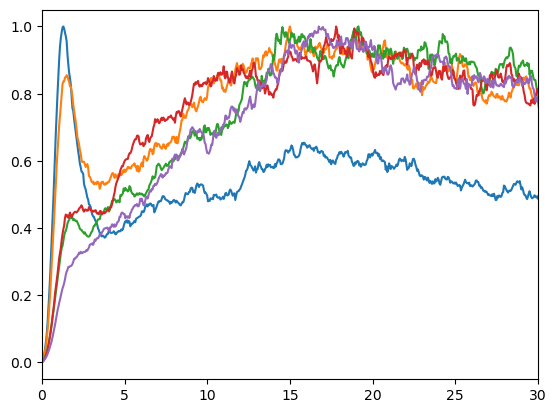

In [6]:
y_plot = mid.T * f[:, None]
y_plot = y_plot / y_plot.max(axis=0)

y_plot = y_plot[:, :5]

plt.plot(f, y_plot)
# plt.xscale('log')
plt.xlim(0, 30)

In [176]:
y_plot.max(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Cross correlation

In [ ]:
val = trials_df.copy()
val = val[val.ctr_hold_bump == False]
starts = val.move_onset_time.values
starts = starts[~np.isnan(starts)]
reach_intervals = np.array([starts - 0.3, starts + 1]).T

lags, xcorr = analysis.cross_correlation(
    max_lag_seconds=0.1, dim_limit=10, processes=20, intervals=reach_intervals
)

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 100/100 [00:05<00:00, 19.83it/s]


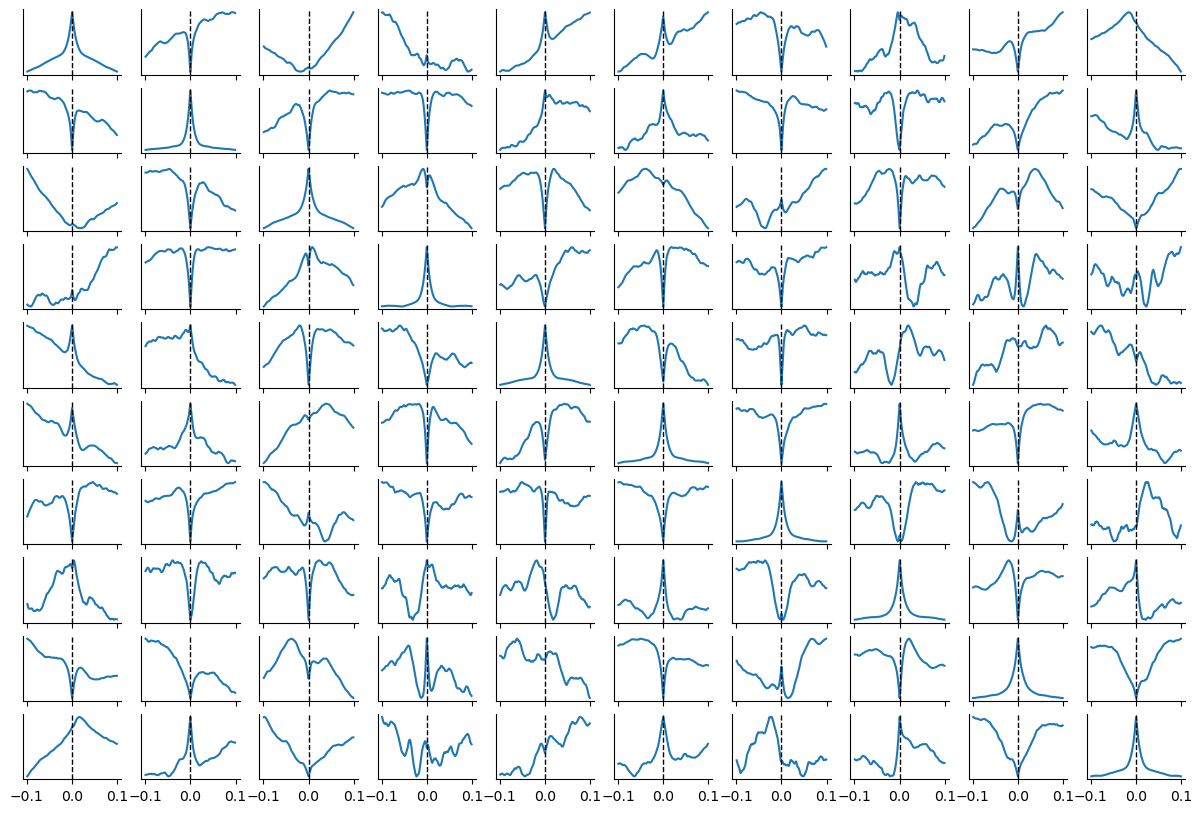

In [ ]:
t_rng = (-0.02, 0.02)
t_rng = (-0.05, 0.05)
# t_rng = -0.1, 0.1
t_rng = -0.2, 0.2
# t_rng = -1,1
# t_rng = -.2,.2

n_plot = 10

n_plot = min(n_plot, xcorr.shape[0])

ind_plot = np.where((lags >= t_rng[0]) & (lags <= t_rng[1]))[0]


fig, ax = plt.subplots(nrows=n_plot, ncols=n_plot, figsize=(15, 10), sharex=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax[i, j].plot(lags[ind_plot], xcorr[i, j][ind_plot])
        ax[i, j].spines[["top", "right"]].set_visible(False)
        # ax[i,j].set_title(f"PC {i+1} vs PC {j+1}")
        ax[i, j].axvline(0, c="k", ls="--", lw=1)
        ax[i, j].set_yticks([])
# plt.xlim(-.1,.1)
# plt.yscale('log')

## Response Curves

8


(-1.0, 3.0)

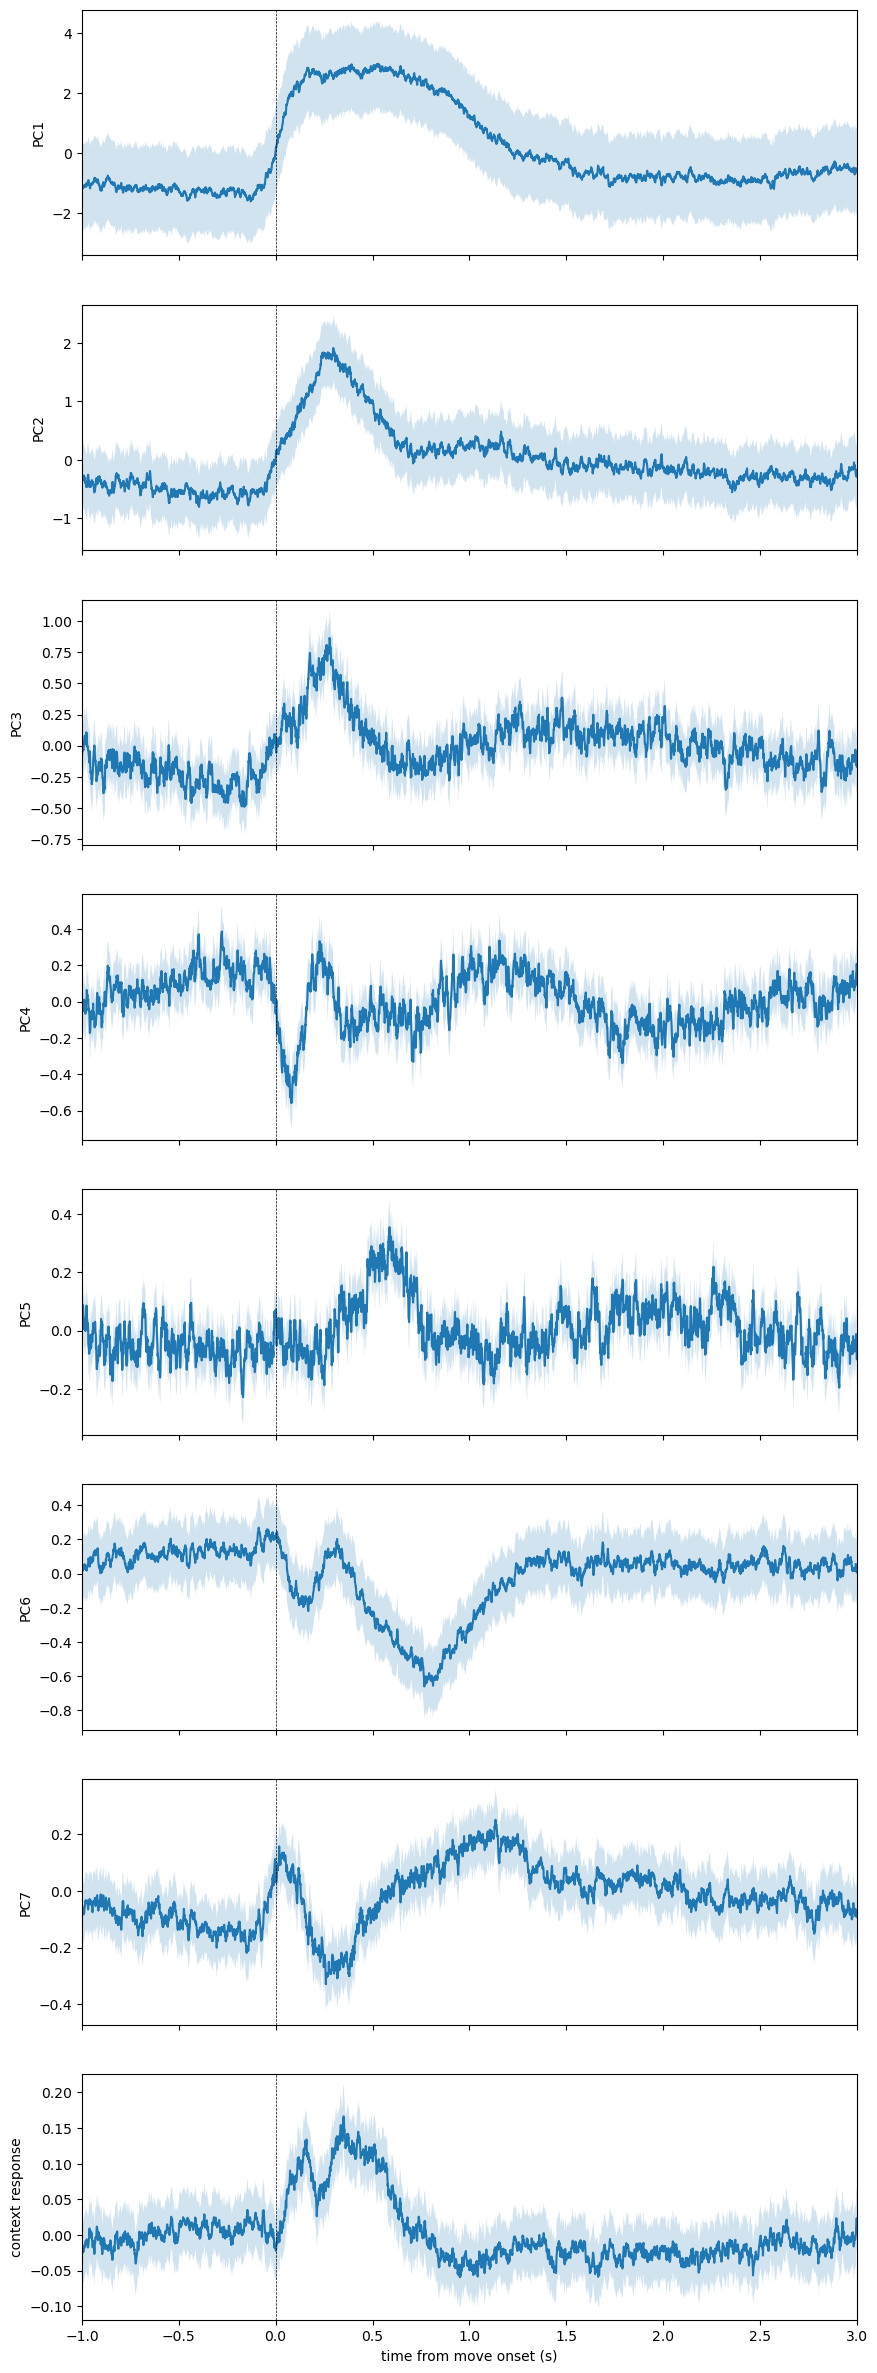

In [320]:
plot_df = trials_df.copy()
plot_df = plot_df[plot_df.ctr_hold_bump == False]
start_times = plot_df.move_onset_time.values
# start_times = trials_df.move_onset_time.values
t_rng = (-1, 3)
fig, ax = plt.subplots(nrows=context_dim, sharex=True, figsize=(10, 30))


response = analysis.alligned_response(start_times, t_rng, pca=True)

response.shape
response = np.mean(response, axis=0)

t = np.linspace(t_rng[0], t_rng[1], response.shape[0])
for i, a in enumerate(ax):
    a.plot(
        t,
        response[:, i],
        label=f"PC{i+1}",
    )
    a.fill_between(
        t,
        response[:, i] - np.std(response[:, i]),
        response[:, i] + np.std(response[:, i]),
        alpha=0.2,
    )
    a.set_ylabel(f"PC{i+1}")
    a.axvline(0, color="k", lw=0.5, ls="--")
# plt.plot(
#     t,
#     response[:, :],
# )
# response = np.array([smooth(response[:, i], 100) for i in range(response.shape[-1])]).T


# plt.plot(response[:, 0], response[:, 1], lw=1)
# plt.scatter(response[0, 0], response[0, 1], s=100, alpha=1,c='k')
# plt.xlabel("PC1")
# plt.ylabel("PC2"    )
print(context_dim)
plt.xlabel("time from move onset (s)")
plt.ylabel("context response")
plt.xlim(t_rng)

0.0
45.0
90.0
135.0
180.0
225.0
270.0
315.0
nan


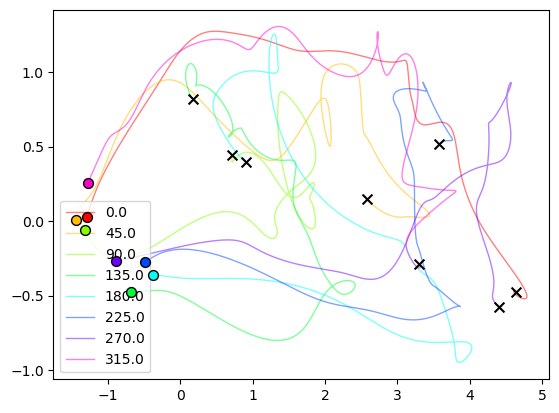

In [321]:
t_rng = (-0.1, 0.5)
# t_rng = (-0.5, 1)
plot_dims = (3, 4)
plot_dims = (0, 1)
plot_dims = (0, 2)
# plot_dims = (1, 4)
smooth_len = 101


def smooth(x, window_len=11, window="hamming"):
    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")
    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")
    if window_len < 3:
        return x
    if window == "hanning":
        w = np.hanning(window_len)
    elif window == "hamming":
        w = np.hamming(window_len)
    elif window == "blackman":
        w = np.blackman(window_len)
    elif window == "gaussian":
        w = np.hanning(window_len)
        w = np.exp(
            -0.5
            * (np.arange(window_len) - window_len // 2) ** 2
            / (window_len // 6) ** 2
        )
        w /= w.sum()
    else:
        raise ValueError("Window is on of 'hanning', 'hamming', 'blackman'")
    y = np.convolve(w / w.sum(), x, mode="valid")
    return y


for direction in np.unique(trials_df.cond_dir.values):
    print(direction)
    if np.isnan(direction):
        continue
    color = plt.cm.hsv(direction / 360)
    # color=None
    val = trials_df.copy()
    val = val[val.ctr_hold_bump == False]
    val = val[val.cond_dir == direction]
    val = val[val.split != "none"]

    # val = trials_df[np.logical_and(trials_df.target_dir == direction, trials_df.result =='A')]
    # val = trials_df[
    #     trials_df.target_dir == direction
    # ]
    start_times = val.move_onset_time.values
    response = analysis.alligned_response(start_times, t_rng, pca=True)
    response = np.nanmean(response, axis=0)
    response = np.array(
        [
            smooth(response[:, i], window_len=smooth_len, window="gaussian")
            for i in range(response.shape[1])
        ]
    ).T
    # plt.plot(response[:, 0], label=direction)
    plt.plot(
        response[:, plot_dims[0]],
        response[:, plot_dims[1]],
        label=direction,
        lw=1,
        color=color,
        alpha=0.5,
    )
    plt.scatter(
        response[0, plot_dims[0]],
        response[0, plot_dims[1]],
        s=50,
        alpha=1,
        color=color,
        zorder=20,
        edgecolor="k",
    )
    plt.scatter(
        response[-1, plot_dims[0]],
        response[-1, plot_dims[1]],
        s=50,
        alpha=1,
        zorder=20,
        marker="x",
        color="k",
    )
    plt.legend()

0.0
45.0
90.0
135.0
180.0
225.0
270.0
315.0
nan


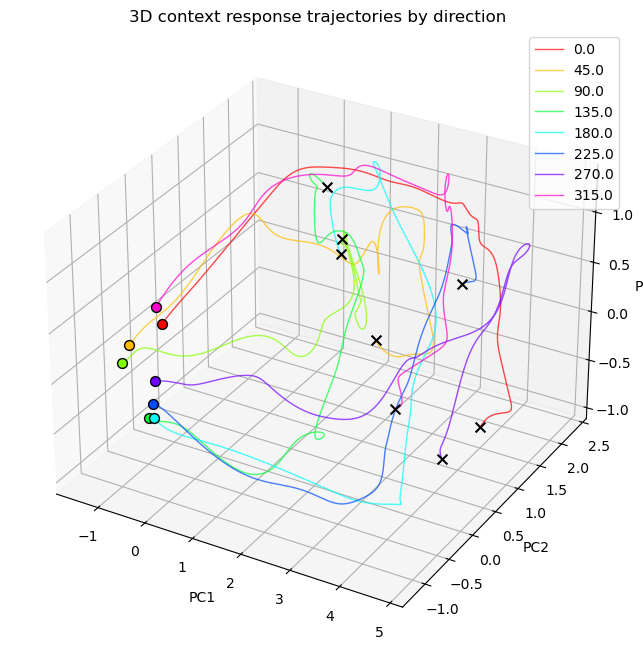

In [322]:
from mpl_toolkits.mplot3d import Axes3D

plot_dims = (0, 1, 2)
# plot_dims = (1, 2, 3)
t_rng = (-0.1, 0.5)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for direction in np.unique(trials_df.cond_dir.values):
    print(direction)
    if np.isnan(direction):
        continue
    color = plt.cm.hsv(direction / 360)
    val = trials_df.copy()
    val = val[val.ctr_hold_bump == False]
    val = val[val.cond_dir == direction]
    val = val[val.split != "none"]

    start_times = val.move_onset_time.values
    response = analysis.alligned_response(start_times, t_rng, pca=True)
    response = np.mean(response, axis=0)
    response = np.array(
        [
            smooth(response[:, i], window_len=101, window="gaussian")
            for i in range(response.shape[1])
        ]
    ).T
    ax.plot(
        response[:, plot_dims[0]],
        response[:, plot_dims[1]],
        response[:, plot_dims[2]],
        label=direction,
        lw=1,
        color=color,
        alpha=0.7,
    )
    ax.scatter(
        response[0, plot_dims[0]],
        response[0, plot_dims[1]],
        response[0, plot_dims[2]],
        s=50,
        alpha=1,
        color=color,
        zorder=20,
        edgecolor="k",
    )
    ax.scatter(
        response[-1, plot_dims[0]],
        response[-1, plot_dims[1]],
        response[-1, plot_dims[2]],
        s=50,
        alpha=1,
        zorder=20,
        marker="x",
        color="k",
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D context response trajectories by direction")
ax.legend()
plt.show()

In [323]:
# # t_rng = (-0.1, 0.5)
# # t_rng = (-0.5, 1)
# t_rng = (-0.5, 1.5)
# fig, ax = plt.subplots(nrows=context_dim, sharex=True, figsize=(10, 30))
# plot_df = trials_df.copy()
# plot_df = plot_df[plot_df.ctr_hold_bump == False]

# def smooth(x, window_len=11, window="hamming"):
#     if x.ndim != 1:
#         raise ValueError("smooth only accepts 1 dimension arrays.")
#     if x.size < window_len:
#         raise ValueError("Input vector needs to be bigger than window size.")
#     if window_len < 3:
#         return x
#     if window == "hanning":
#         w = np.hanning(window_len)
#     elif window == "hamming":
#         w = np.hamming(window_len)
#     elif window == "blackman":
#         w = np.blackman(window_len)
#     elif window == "gaussian":
#         w = np.hanning(window_len)
#         w = np.exp(
#             -0.5
#             * (np.arange(window_len) - window_len // 2) ** 2
#             / (window_len // 6) ** 2
#         )
#         w /= w.sum()
#     else:
#         raise ValueError("Window is on of 'hanning', 'hamming', 'blackman'")
#     y = np.convolve(w / w.sum(), x, mode="valid")
#     return y


# for direction in np.unique(plot_df.cond_dir.values):
#     print(direction)
#     if np.isnan(direction):
#         continue
#     color = plt.cm.hsv(direction / 360)
#     # color = plt.cm.twilight(direction / 360)
#     # color = None
#     val = plot_df.copy()
#     val = val[val.ctr_hold_bump == False]
#     val = val[val.cond_dir == direction]
#     val = val[val.split != "none"]

#     start_times = val.move_onset_time.values
#     response = analysis.alligned_response(start_times, t_rng, pca=True)
#     response = np.nanmean(response, axis=0)
#     response = np.array(
#         [
#             smooth(response[:, i], window_len=11, window="gaussian")
#             for i in range(response.shape[1])
#         ]
#     ).T
#     t_interp_rng = np.linspace(t_rng[0], t_rng[1], response.shape[0])
#     for i, a in enumerate(ax):
#         a.plot(t_interp_rng, response[:, i], label=direction, color=color)

# plt.legend()
# plt.xlim(-0.1, 0.5)

## Compare active and bump Trajectories

0.0
45.0
90.0
135.0
180.0
225.0
270.0
315.0
nan


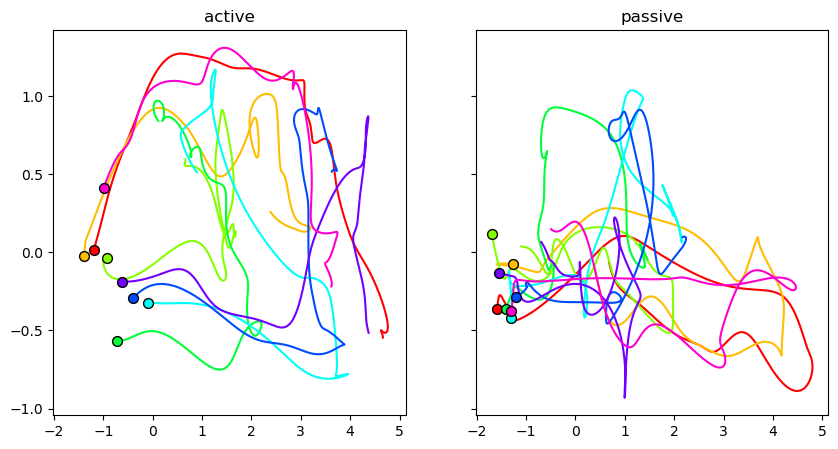

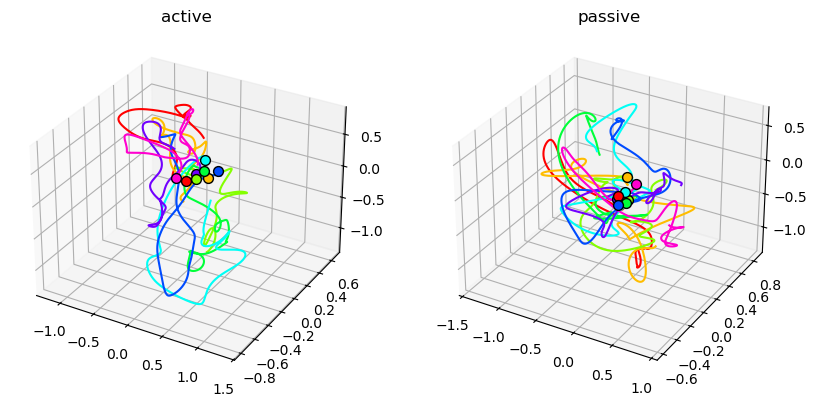

In [ ]:
t_rng = (-0.1, 0.5)
smooth_len = 101
plot_dims = (0, 2)
dims_3d = (3, 4, 5)

cond_dfs = dict()

plot_df = trials_df.copy()
plot_df = plot_df[~np.isnan(plot_df.move_onset_time)]
plot_df = plot_df[plot_df.ctr_hold_bump == False]
cond_dfs["active"] = plot_df

plot_df = trials_df.copy()
plot_df = plot_df[~np.isnan(plot_df.move_onset_time)]
plot_df = plot_df[plot_df.ctr_hold_bump == True]
cond_dfs["passive"] = plot_df

fig, ax = plt.subplots(ncols=len(cond_dfs), sharex=True, sharey=True, figsize=(10, 5))
fig3d = plt.figure(figsize=(10, 8))
ax3d = []
ax3d.append(fig3d.add_subplot(121, projection="3d"))
ax3d.append(fig3d.add_subplot(122, projection="3d"))

for direction in np.unique(trials_df.cond_dir.values):
    print(direction)
    if np.isnan(direction):
        continue
    color = plt.cm.hsv(direction / 360)
    for j, (cond, plot_df) in enumerate(cond_dfs.items()):
        val = plot_df.copy()
        val = val[val.cond_dir == direction]
        # val = val[val.split != "none"]

        start_times = val.move_onset_time.values
        response = analysis.alligned_response(start_times, t_rng, pca=True)
        response = np.nanmean(response, axis=0)
        response = np.array(
            [
                smooth(response[:, i], window_len=smooth_len, window="gaussian")
                for i in range(response.shape[1])
            ]
        ).T
        t_interp_rng = np.linspace(t_rng[0], t_rng[1], response.shape[0])
        a = ax[j]
        a.plot(
            response[:, plot_dims[0]],
            response[:, plot_dims[1]],
            label=direction,
            color=color,
        )
        a.scatter(
            response[0, plot_dims[0]],
            response[0, plot_dims[1]],
            s=50,
            alpha=1,
            color=color,
            zorder=20,
            edgecolor="k",
        )
        a.set_title(cond)

        a = ax3d[j]
        a.plot(
            response[:, dims_3d[0]],
            response[:, dims_3d[1]],
            response[:, dims_3d[2]],
            label=direction,
            color=color,
        )
        a.scatter(
            response[0, dims_3d[0]],
            response[0, dims_3d[1]],
            response[0, dims_3d[2]],
            s=50,
            alpha=1,
            color=color,
            zorder=20,
            edgecolor="k",
        )
        a.set_title(cond)

fig3d.savefig(
    figure_folder / f"_decoding_avg_traj_3d.svg",
)

In [332]:
context_dim

8

In [ ]:
t_rng = (0, 0.5)

results = {}

plot_df = trials_df.copy()
plot_df = plot_df[~np.isnan(plot_df.move_onset_time)]
plot_df = plot_df[plot_df.ctr_hold_bump == False]
start_times = plot_df.move_onset_time.values
response = analysis.alligned_response(start_times, t_rng, pca=True)
directions = plot_df.target_dir.values
results["active"] = dict(
    response=response,
    directions=directions,
)

print(len(response), len(directions), len(plot_df))
raise ValueError

plot_df = trials_df.copy()
plot_df = plot_df[plot_df.ctr_hold_bump == True]
start_times = plot_df.move_onset_time.values
response = analysis.alligned_response(start_times, t_rng, pca=True)
directions = plot_df.bump_dir.values
results["passive"] = dict(
    response=response,
    directions=directions,
)


fig, ax = plt.subplots(ncols=2)
for i, key in enumerate(["active", "passive"]):
    response = results[key]["response"]
    directions = results[key]["directions"]
    for direction in np.unique(directions):
        if np.isnan(direction):
            continue
        color = plt.cm.hsv(direction / 360)
        val_inds = np.where(directions == direction)[0]
        resp_dir = response[val_inds]
        resp_dir_mean = np.mean(resp_dir, axis=0)
        t = np.linspace(t_rng[0], t_rng[1], resp_dir_mean.shape[0])
        ax[i].plot(
            t,
            resp_dir_mean[:, 0],
            label=direction,
            color=color,
        )
        ax[i].fill_between(
            t,
            resp_dir_mean[:, 0] - np.std(resp_dir[:, 0]),
            resp_dir_mean[:, 0] + np.std(resp_dir[:, 0]),
            alpha=0.2,
            color=color,
        )
        ax[i].set_title(f"{key} context PC1 response")
        ax[i].axvline(0, color="k", lw=0.5, ls="--")
        ax[i].set_xlabel("time from onset (s)")
        ax[i].set_ylabel("context PC1 response")
    ax[i].legend()

239 256 256


ValueError: 

In [ ]:
start_times
trials_df
np.unique(start_times)

array([   4.075,   14.656,   18.508,   22.247,   44.107,   51.106,
         59.721,   66.443,   71.549,   79.118,   87.073,  112.859,
        122.917,  127.265,  138.991,  150.35 ,  158.541,  161.397,
        164.247,  170.838,  174.591,  178.84 ,  182.32 ,  195.353,
        198.564,  239.367,  242.946,  246.416,  250.528,  254.02 ,
        264.409,  267.657,  270.967,  272.919,  318.552,  322.361,
        325.206,  336.052,  339.561,  354.442,  358.759,  362.78 ,
        366.721,  381.072,  386.354,  391.361,  402.287,  425.086,
        436.569,  440.095,  442.79 ,  446.214,  449.739,  462.404,
        477.991,  499.11 ,  519.228,  526.404,  535.697,  538.966,
        544.817,  552.946,  558.171,  562.546,  566.625,  571.106,
        576.256,  578.972,  581.792,  584.425,  591.212,  594.478,
        597.365,  601.902,  612.297,  620.019,  628.705,  634.729,
        639.769,  646.982,  656.621,  659.979,  665.761,  669.504,
        671.922,  677.689,  685.269,  688.29 ,  691.307,  697.

In [ ]:
t_plot = (0, 1)
c_data = analysis.c_pca_interp
marks = start_times

t_data = analysis.t_interp
dt = np.median(np.diff(t_data))
window = int(t_plot[0] / dt), int(t_plot[1] / dt)
mark_inds = np.digitize(marks, t_data) - 1
mark_inds = mark_inds[
    np.logical_and(mark_inds + window[0] >= 0, mark_inds + window[1] < c_data.shape[0])
]
print(len(marks), len(mark_inds))

256 255


In [289]:
analysis.t_interp.min(), trials_df.move_onset_time.min()

analysis.t_interp.max(), trials_df.move_onset_time.max()

(2223.445000000002, 2222.581)

In [279]:
plot_df.columns

Index(['start_time', 'stop_time', 'result', 'ctr_hold', 'ctr_hold_bump',
       'bump_dir', 'target_on_time', 'target_dir', 'go_cue_time', 'bump_time',
       'move_onset_time', 'cond_dir', 'split'],
      dtype='object')

## Power spectrums

In [11]:
# starts = trials_df["start_time"].values
val = trials_df.copy()
val = val[val.ctr_hold_bump == False]
# val = val[val.cond_dir == direction]
# val = val[val.split != "none"]
starts = val.move_onset_time.values

reach_intervals = np.array([starts - 1, starts + 1.5]).T

In [12]:
f, mid, lo, hi = analysis.power_spectrum(
    intervals=reach_intervals, pca=True, window_size=500
)

Text(0.5, 1.0, 'context power spectrums')

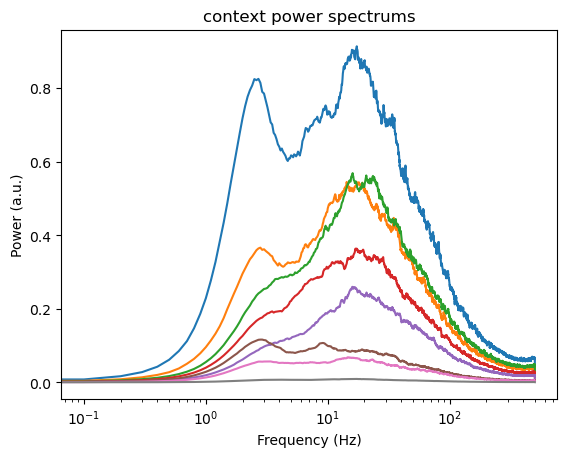

In [13]:
plt.plot(f, mid.T * f[:, None])
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (a.u.)")
plt.title("context power spectrums")

# Behavior Decoding

In [30]:
analysis_ = analysis_dict["movement"]

df = trials_df[trials_df.ctr_hold_bump == False]
reach_intervals = df.move_onset_time.values
train_rng = (-0.1, 0.5)
# train_rng = (-0.1, 1)
train_rng = (-0.5, 1.5)

reach_intervals = np.array(
    [reach_intervals + train_rng[0], reach_intervals + train_rng[1]]
).T

bins = np.linspace(-15, 15, 100)
c_binned, b1, b2 = analysis_.bin_context_by_feature_2d(
    feature_1=behavior_df["hand_pos_x"].values,
    feature_2=behavior_df["hand_pos_y"].values,
    feature_1_times=behavior_df.index.values,
    feature_2_times=behavior_df.index.values,
    valid_intervals=reach_intervals,
    pca=True,
    interpolated=True,
    bins_1=bins,
    bins_2=bins,
)

c_mid = np.array(
    [
        [
            np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
            for b in row
        ]
        for row in c_binned
    ]
)

/tmp/ipykernel_4073665/570919766.py:29: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)


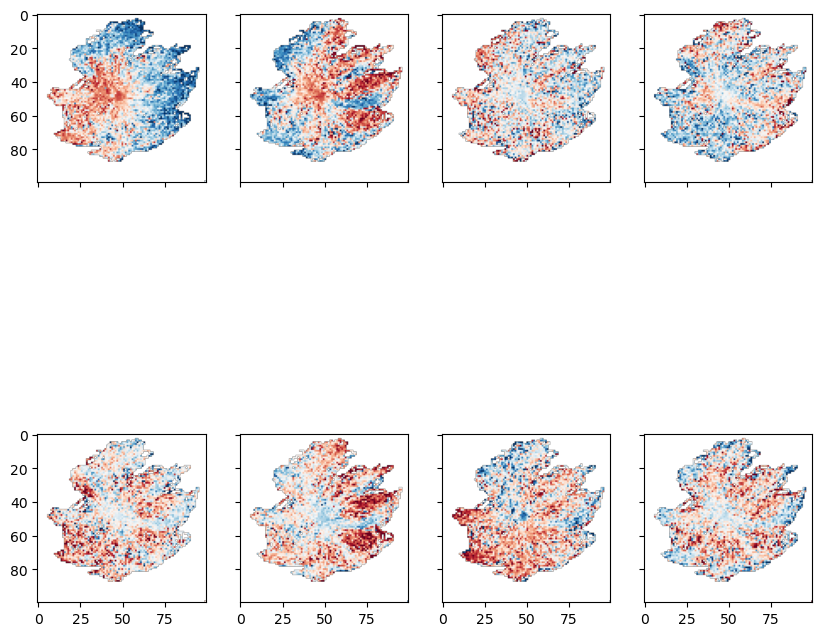

In [31]:
# val = val - np.nanmean(val)
n_r = int(np.sqrt(context_dim))
n_c = int(np.ceil(context_dim / n_r))
fig, ax = plt.subplots(nrows=n_r, ncols=n_c, figsize=(10, 10), sharex=True, sharey=True)
ax = np.ravel(ax)
for i, a in enumerate(ax):
    val = c_mid[:, :, i].T
    val = val / np.nanpercentile(np.abs(val), 97)

    a.imshow(val, cmap="RdBu", clim=(-1, 1))
    # plt.colorbar()

In [127]:
behavior_df.index.values
reach_intervals = reach_intervals[~np.isnan(reach_intervals).any(axis=1)]

In [33]:
behavior_df.columns

Index(['muscle_vel_x', 'muscle_vel_y', 'muscle_len_x', 'muscle_len_y',
       'joint_vel_x', 'joint_vel_y', 'joint_ang_x', 'joint_ang_y',
       'hand_vel_x', 'hand_vel_y', 'hand_pos_x', 'hand_pos_y', 'force_x',
       'force_y'],
      dtype='object')

In [139]:
train_df.target_dir.value_counts().min()

14

## Fit and test

In [ ]:
# Define decodeer type and fit
balance_groups = True

train_df = trials_df[trials_df.split == "train"]
train_df = train_df[train_df.ctr_hold_bump == False]

# train_rng = (-0.1, 0.5)
train_rng = (-0.1, 0.5)
# train_rng = (0.1, 0.5)
# train_rng = (-.5,1.5)


train_intervals = train_df.move_onset_time.values
if balance_groups:
    min_count = train_df.target_dir.value_counts().min()
    balanced_starts = []
    for direction in train_df.target_dir.unique():
        dir_starts = train_df[train_df.target_dir == direction].move_onset_time.values
        if len(dir_starts) > min_count:
            dir_starts = np.random.choice(dir_starts, size=min_count, replace=False)
        balanced_starts.extend(dir_starts)
    train_intervals = np.array(balanced_starts)

train_intervals = np.array(
    [train_intervals + train_rng[0], train_intervals + train_rng[1]]
).T


t_feature = behavior_df.index.values
feature_names = ["hand_pos_x", "hand_pos_y"]
feature_names = ["hand_vel_x", "hand_vel_y"]
feature_names = ["mom_x", "mom_y", "mom_z"]
# feature_names = ["force_x","force_y"]
feature = behavior_df[feature_names].values

feature_names = [name for name in joint_behavior_df.columns if "ang" in name]
feature = joint_behavior_df[feature_names].values

feature_names = expanded_behavior_df.columns.tolist()
feature_names = ["pectoralis_sup_len", "pectoralis_inf_len"]  # top 3 performance
group_name = "pectoralis_lengths"


feature_names = ["hand_vel_x", "hand_vel_y"]
group_name = "hand_velocity"
feature = expanded_behavior_df[feature_names].values


# feature = behavior_df[["hand_pos_y"]].values
def weight_function(x):
    return np.exp(-0.5 * (x / 0.5) ** 2)


print(np.nanmin(feature), np.nanmax(feature))
# analysis.initialize_decoder("knn", n_neighbors=30, weights='distance', metric='cosine')
analysis.initialize_decoder(
    model_type="knn",
    n_neighbors=300,
    # feature_prediction_delay=-.08,
    # weights="uniform",
    weights="distance",
    # weights=weight_function,
    # metric="cosine",
    metric="euclidean",
)

# analysis.initialize_decoder(
#     "discretized_regression", n_bins=100, max_iter=1000, balance_groups=True, multidim=True
# )

# analysis.initialize_decoder("linear", feature_prediction_delay=0.05)
# # analysis.fit_decoder(feature, t_feature, intervals=train_intervals,pca=False,interpolate=True, smooth_context=20)

analysis.fit_decoder(
    feature,
    t_feature,
    intervals=train_intervals,
    # pca=True,
    pca=False,
    decode_dim=slice(0, None),
    interpolate=True,
    smooth_context=30,
    # balance_features=True,
    balance_features_bins=int(20),
    balance_features_min_count=50,
)

-72.77814989820557 63.89650221889129


In [272]:
# Decode on test set

test_df = trials_df[trials_df.split == "val"]
test_df = test_df[test_df.ctr_hold_bump == False]
# test_df = test_df[test_df.ctr_hold_bump == True]


# test_df = train_df

test_intervals = test_df.move_onset_time.values
test_rng = (-0.5, 1)
# test_rng = (-0.1, 0.5)
test_intervals = np.array(
    [test_intervals + test_rng[0], test_intervals + test_rng[1]]
).T

# test_intervals = test_intervals[:5]

from tqdm import tqdm

predicted = []
for interval in tqdm(test_intervals):
    predicted.append(
        analysis.predict_decoder(interval, interpolate=True, smooth_context=30)
    )

test_directions = test_df.cond_dir.values
test_bump = test_df.ctr_hold_bump.values

100%|██████████| 52/52 [00:10<00:00,  5.07it/s]


Text(0.5, 0, 'time from move onset (s)')

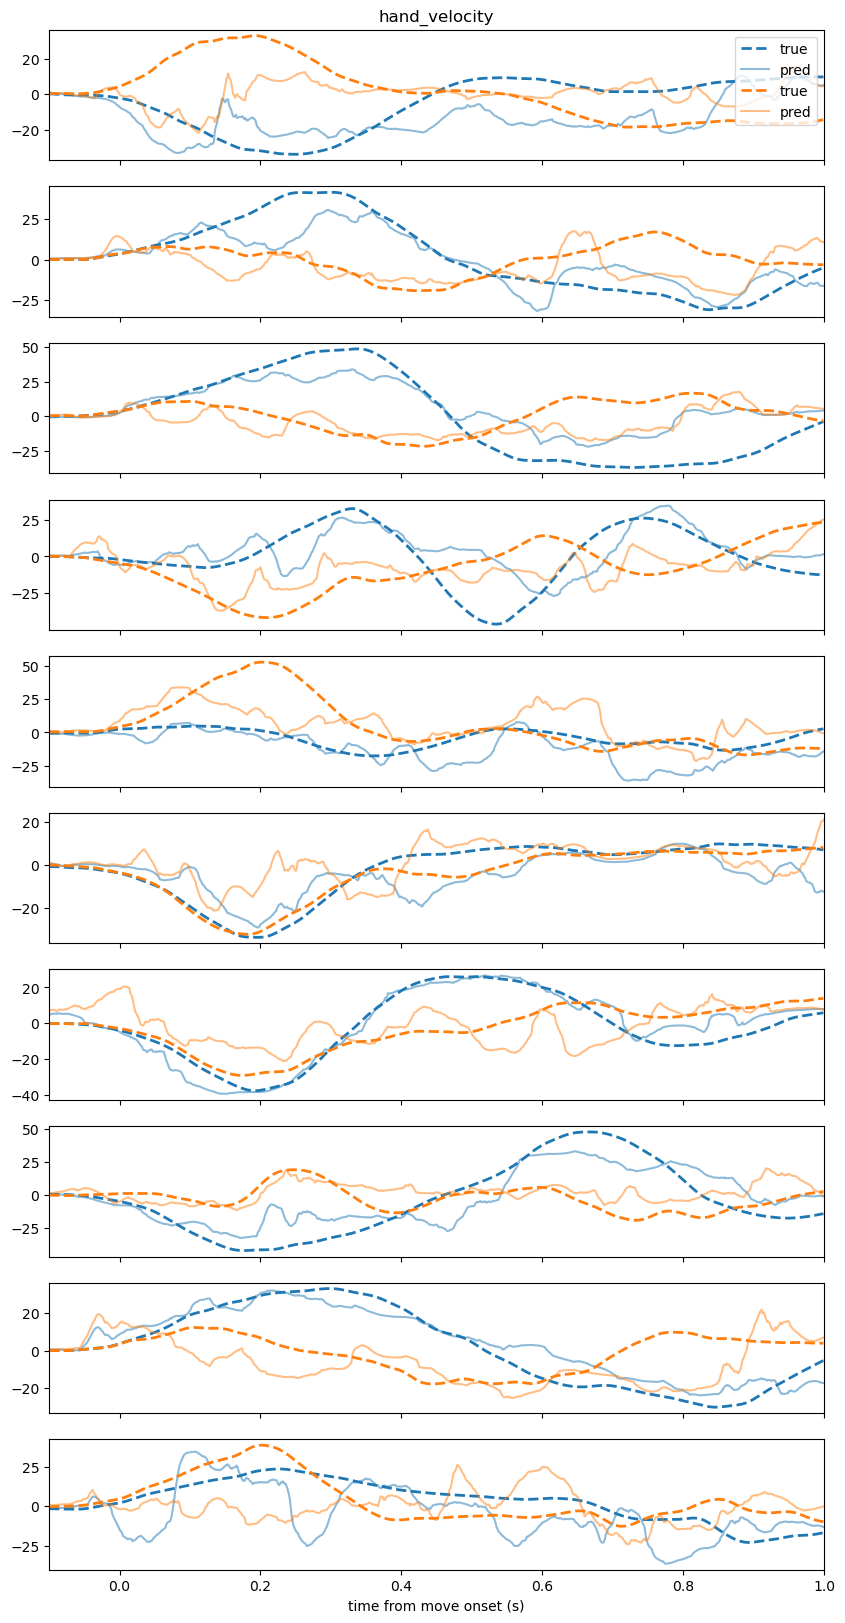

In [273]:
# Example result traces

fig, ax = plt.subplots(nrows=10, sharex=True, figsize=(10, 20))

ind = np.where(np.logical_and(test_directions == 0, test_bump == 1))[0]
ind = np.where(test_bump == 0)[0][10:]
for i, ind_i in enumerate(ind[:10]):
    t, pred = predicted[ind_i]

    # pred[:, 0] = np.convolve(
    #     pred[:, 0], np.hanning(21) / np.hanning(21).sum(), mode="same"
    # )
    # pred[:, 1] = np.convolve(
    #     pred[:, 1], np.hanning(21) / np.hanning(21).sum(), mode="same"
    # )
    # pred = gaussian_filter1d(pred, 10, axis=0, mode="nearest")

    if t.size == 0:
        continue
    ind_behavior = np.digitize(t, behavior_df.index.values) - 1

    for j in range(feature.shape[1]):
        ax[i].plot(
            behavior_df.index.values[ind_behavior] - t[0] + test_rng[0],
            feature[ind_behavior, j],
            color=f"C{j}",
            ls="--",
            lw=2,
            # s=1,
            label="true",
        )
        ax[i].plot(
            t - t[0] + test_rng[0], pred[:, j], color=f"C{j}", alpha=0.5, label="pred"
        )

ax[0].set_title(group_name)
# ax[0].set_title("Hand position decoding")
ax[0].legend(loc="upper right")
ax[0].set_xlim(-0.1, 1)
plt.xlabel("time from move onset (s)")
# for t,pred in predicted[:10]:
#     if t.size==0: continue
#     ind_behavior = np.digitize(t, behavior_df.index.values) - 1
#     plt.plot(t-t[0], pred, color='C0', alpha=0.3)
#     plt.scatter(behavior_df.index.values[ind_behavior]-t[0], feature[ind_behavior,0], color='k', s=1)

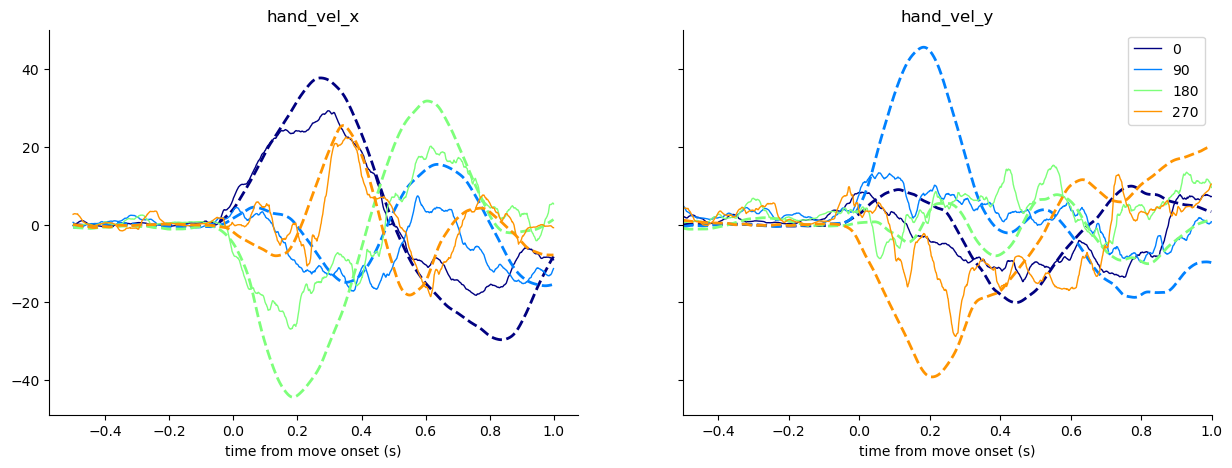

In [274]:
# Average results by reach direction

fig, ax = plt.subplots(ncols=len(feature_names), figsize=(15, 5), sharey=True)
if len(feature_names) == 1:
    ax = [ax]

directions = [0, 90, 180, 270]
# directions = [d+45. for d in directions]
for direction in directions:
    color = plt.cm.jet(direction / 360)
    ind = np.where(np.logical_and(test_directions == direction, test_bump == 0))[0]
    # for i, ind_i in enumerate(ind[:5]):
    #     t, pred = predicted[ind_i]
    #     if t.size == 0:
    #         continue
    #     # ind_behavior = np.digitize(t, behavior_df.index.values) - 1
    #     plt.plot(t - t[0] + test_rng[0], pred, color=color, alpha=0.1)

    mean_pred = np.mean(
        [predicted[ind_i][1] for ind_i in ind if predicted[ind_i][1].size > 0], axis=0
    )
    mean_t = predicted[ind[0]][0]

    for index, a in enumerate(ax):
        a.plot(
            mean_t - mean_t[0] + test_rng[0],
            mean_pred[:, index],
            color=color,
            lw=1,
            label=direction,
        )

        true_vals = []
        for ind_i in ind:
            t, pred = predicted[ind_i]
            if t.size == 0:
                continue
            ind_behavior = np.digitize(t, behavior_df.index.values) - 1
            true_vals.append(feature[ind_behavior, index])
        a.plot(
            mean_t - mean_t[0] + test_rng[0],
            np.mean(true_vals, axis=0),
            color=color,
            lw=2,
            ls="--",
        )
        a.set_title(f"{feature_names[index]}")
        a.spines[["top", "right"]].set_visible(False)
        a.set_xlabel("time from move onset (s)")

plt.legend()
plt.xlim(-0.5, 1)
# plt.xlim(-0.1, 0.5)

fig.savefig(
    figure_folder / f"{group_name}_decoding_avg_traj.png",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
error = []
preds = []
true_vals = []
eval_window = (0, 0.5)

for ind_i in range(len(predicted)):
    t, pred = predicted[ind_i]
    if t.size == 0:
        continue
    ind_plot = np.logical_and(
        t - t[0] + test_rng[0] >= eval_window[0],
        t - t[0] + test_rng[0] <= eval_window[1],
    )

    if t.size == 0:
        continue
    ind_behavior = np.digitize(t, behavior_df.index.values) - 1

    error_i = feature[ind_behavior, :] - pred
    error.append(error_i[ind_plot, :])
    preds.append(pred[ind_plot, :])
    true_vals.append(feature[ind_behavior, :][ind_plot, :])

error = np.concatenate(error, axis=0)
preds = np.concatenate(preds, axis=0)
true_vals = np.concatenate(true_vals, axis=0)

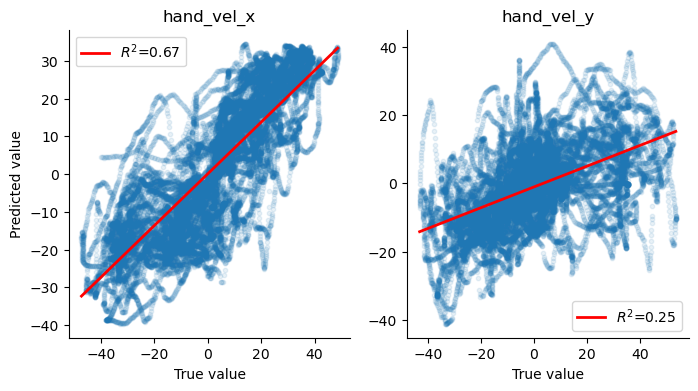

In [ ]:
from scipy.stats import linregress

nrows = 1
ncols = feature.shape[1]

if ncols > 4:
    nrows = ncols // 4 + int(ncols % 4 > 0)
    ncols = 4

fig, ax = plt.subplots(nrows, ncols, figsize=(4 * feature.shape[1], 4))

for i, a in enumerate(np.ravel(ax)):
    a.scatter(true_vals[:, i], preds[:, i], alpha=0.1, s=10)
    slope, intercept, r_value, p_value, std_err = linregress(
        true_vals[:, i], preds[:, i]
    )
    a.plot(
        np.array([true_vals[:, i].min(), true_vals[:, i].max()]),
        intercept + slope * np.array([true_vals[:, i].min(), true_vals[:, i].max()]),
        color="red",
        lw=2,
        label=f"$R^2$={r_value**2:.2f}",
    )
    a.set_xlabel("True value")

    a.set_title(feature_names[i])
    a.legend()
    a.spines[["right", "top"]].set_visible(False)
    if i > 10:
        continue
ax[0].set_ylabel("Predicted value")

fig.savefig(
    figure_folder / f"{group_name}_decoding_scatter.svg",
)

PosixPath('/home/sambray/Documents/c3po/Figures/monkey_s1_reach/monkey_s1_bump_reach_REACH_ONLY/pectoralis_lengths_decoding_scatter.svg')

<BarContainer object of 102 artists>

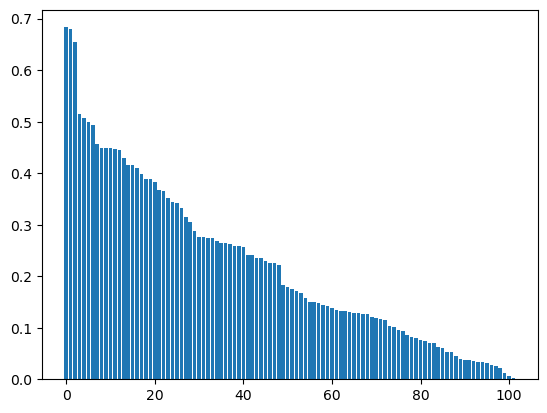

In [ ]:
rvals = []
pvals = []
for i, name in enumerate(feature_names):
    a.scatter(true_vals[:, i], preds[:, i], alpha=0.1, s=10)
    slope, intercept, r_value, p_value, std_err = linregress(
        true_vals[:, i], preds[:, i]
    )
    rvals.append(r_value**2)
    pvals.append(p_value)
rvals = np.array(rvals)
pvals = np.array(pvals)
ind = np.argsort(-rvals)

plot_names = np.array(feature_names)[ind]
rvals = rvals[ind]
pvals = pvals[ind]
plt.bar(np.arange(len(rvals)), rvals)

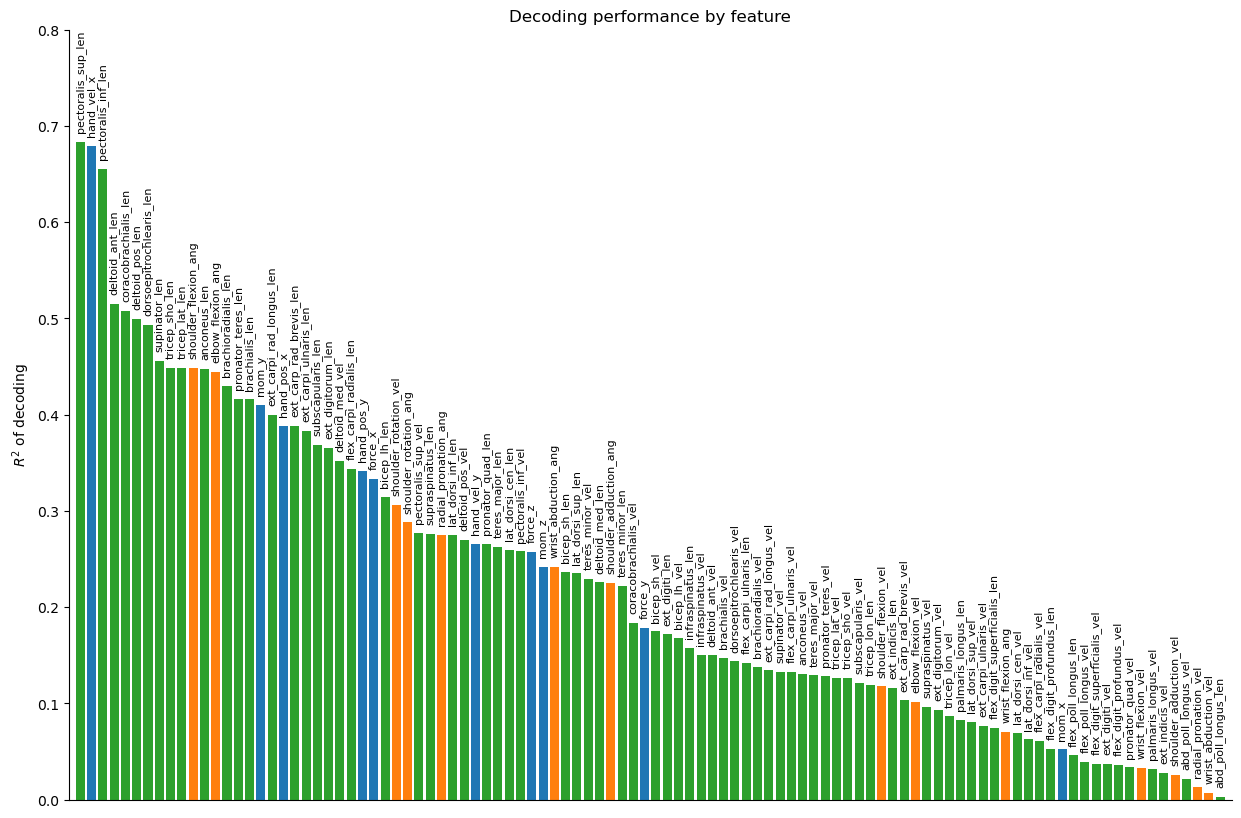

In [ ]:
# np.array(feature_names)[ind]
plot_groups = ["none" for _ in range(len(rvals))]
for i, name in enumerate(plot_names):
    if name in behavior_df.columns:
        plot_groups[i] = "hand"
    if name in joint_behavior_df.columns:
        plot_groups[i] = "joint"
    if name in muscle_behavior_df.columns:
        plot_groups[i] = "muscle"

color_map = {
    "hand": "C0",
    "joint": "C1",
    "muscle": "C2",
}
plot_colors = [color_map[g] for g in plot_groups]

fig, ax = plt.subplots(figsize=(15, 10))
for i, name in enumerate(plot_names):
    ax.bar(i, rvals[i], color=plot_colors[i])
    ax.text(i, rvals[i] + 0.01, name, rotation=90, ha="center", va="bottom", fontsize=8)
ax.set_ylabel("$R^2$ of decoding")
ax.set_title("Decoding performance by feature")
ax.spines[["top", "right"]].set_visible(False)
plt.ylim(0, 0.8)
plt.xticks([])
plt.xlim(-1, len(rvals))

fig.savefig(figure_folder / "feature_decoding_performance_bar.svg")

In [251]:
plot_names[:3]

array(['pectoralis_sup_len', 'hand_vel_x', 'pectoralis_inf_len'],
      dtype='<U28')

Text(0.5, 1.0, 'Example hand position trajectories: true (dashed) vs predicted (solid)')

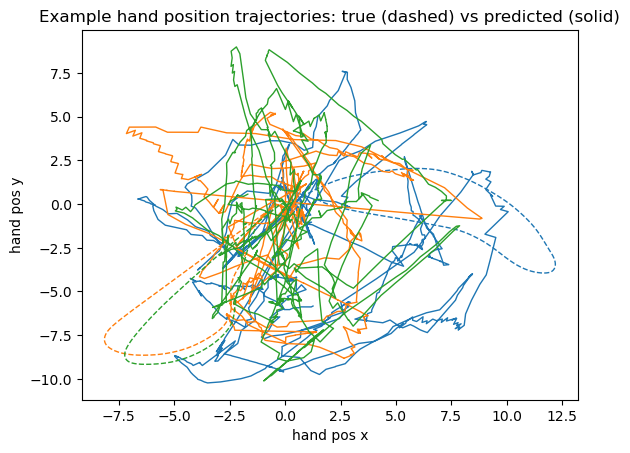

In [42]:
for n_i, i in enumerate(np.random.choice(len(predicted), size=3, replace=False)):

    t_pred, pred = predicted[i]
    ind_behavior = np.digitize(t_pred, behavior_df.index.values) - 1

    true_val = feature[ind_behavior, :]

    plt.plot(true_val[:, 0], true_val[:, 1], color=f"C{n_i}", ls="--", lw=1)
    plt.plot(pred[:, 0], pred[:, 1], color=f"C{n_i}", lw=1)

plt.xlabel("hand pos x")
plt.ylabel("hand pos y")
plt.title("Example hand position trajectories: true (dashed) vs predicted (solid)")

In [188]:
pred

array([], dtype=float64)

In [23]:
from tqdm import tqdm

# Bin by feature


0it [00:00, ?it/s]/tmp/ipykernel_4073665/237050327.py:33: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
78it [02:04,  1.60s/it]


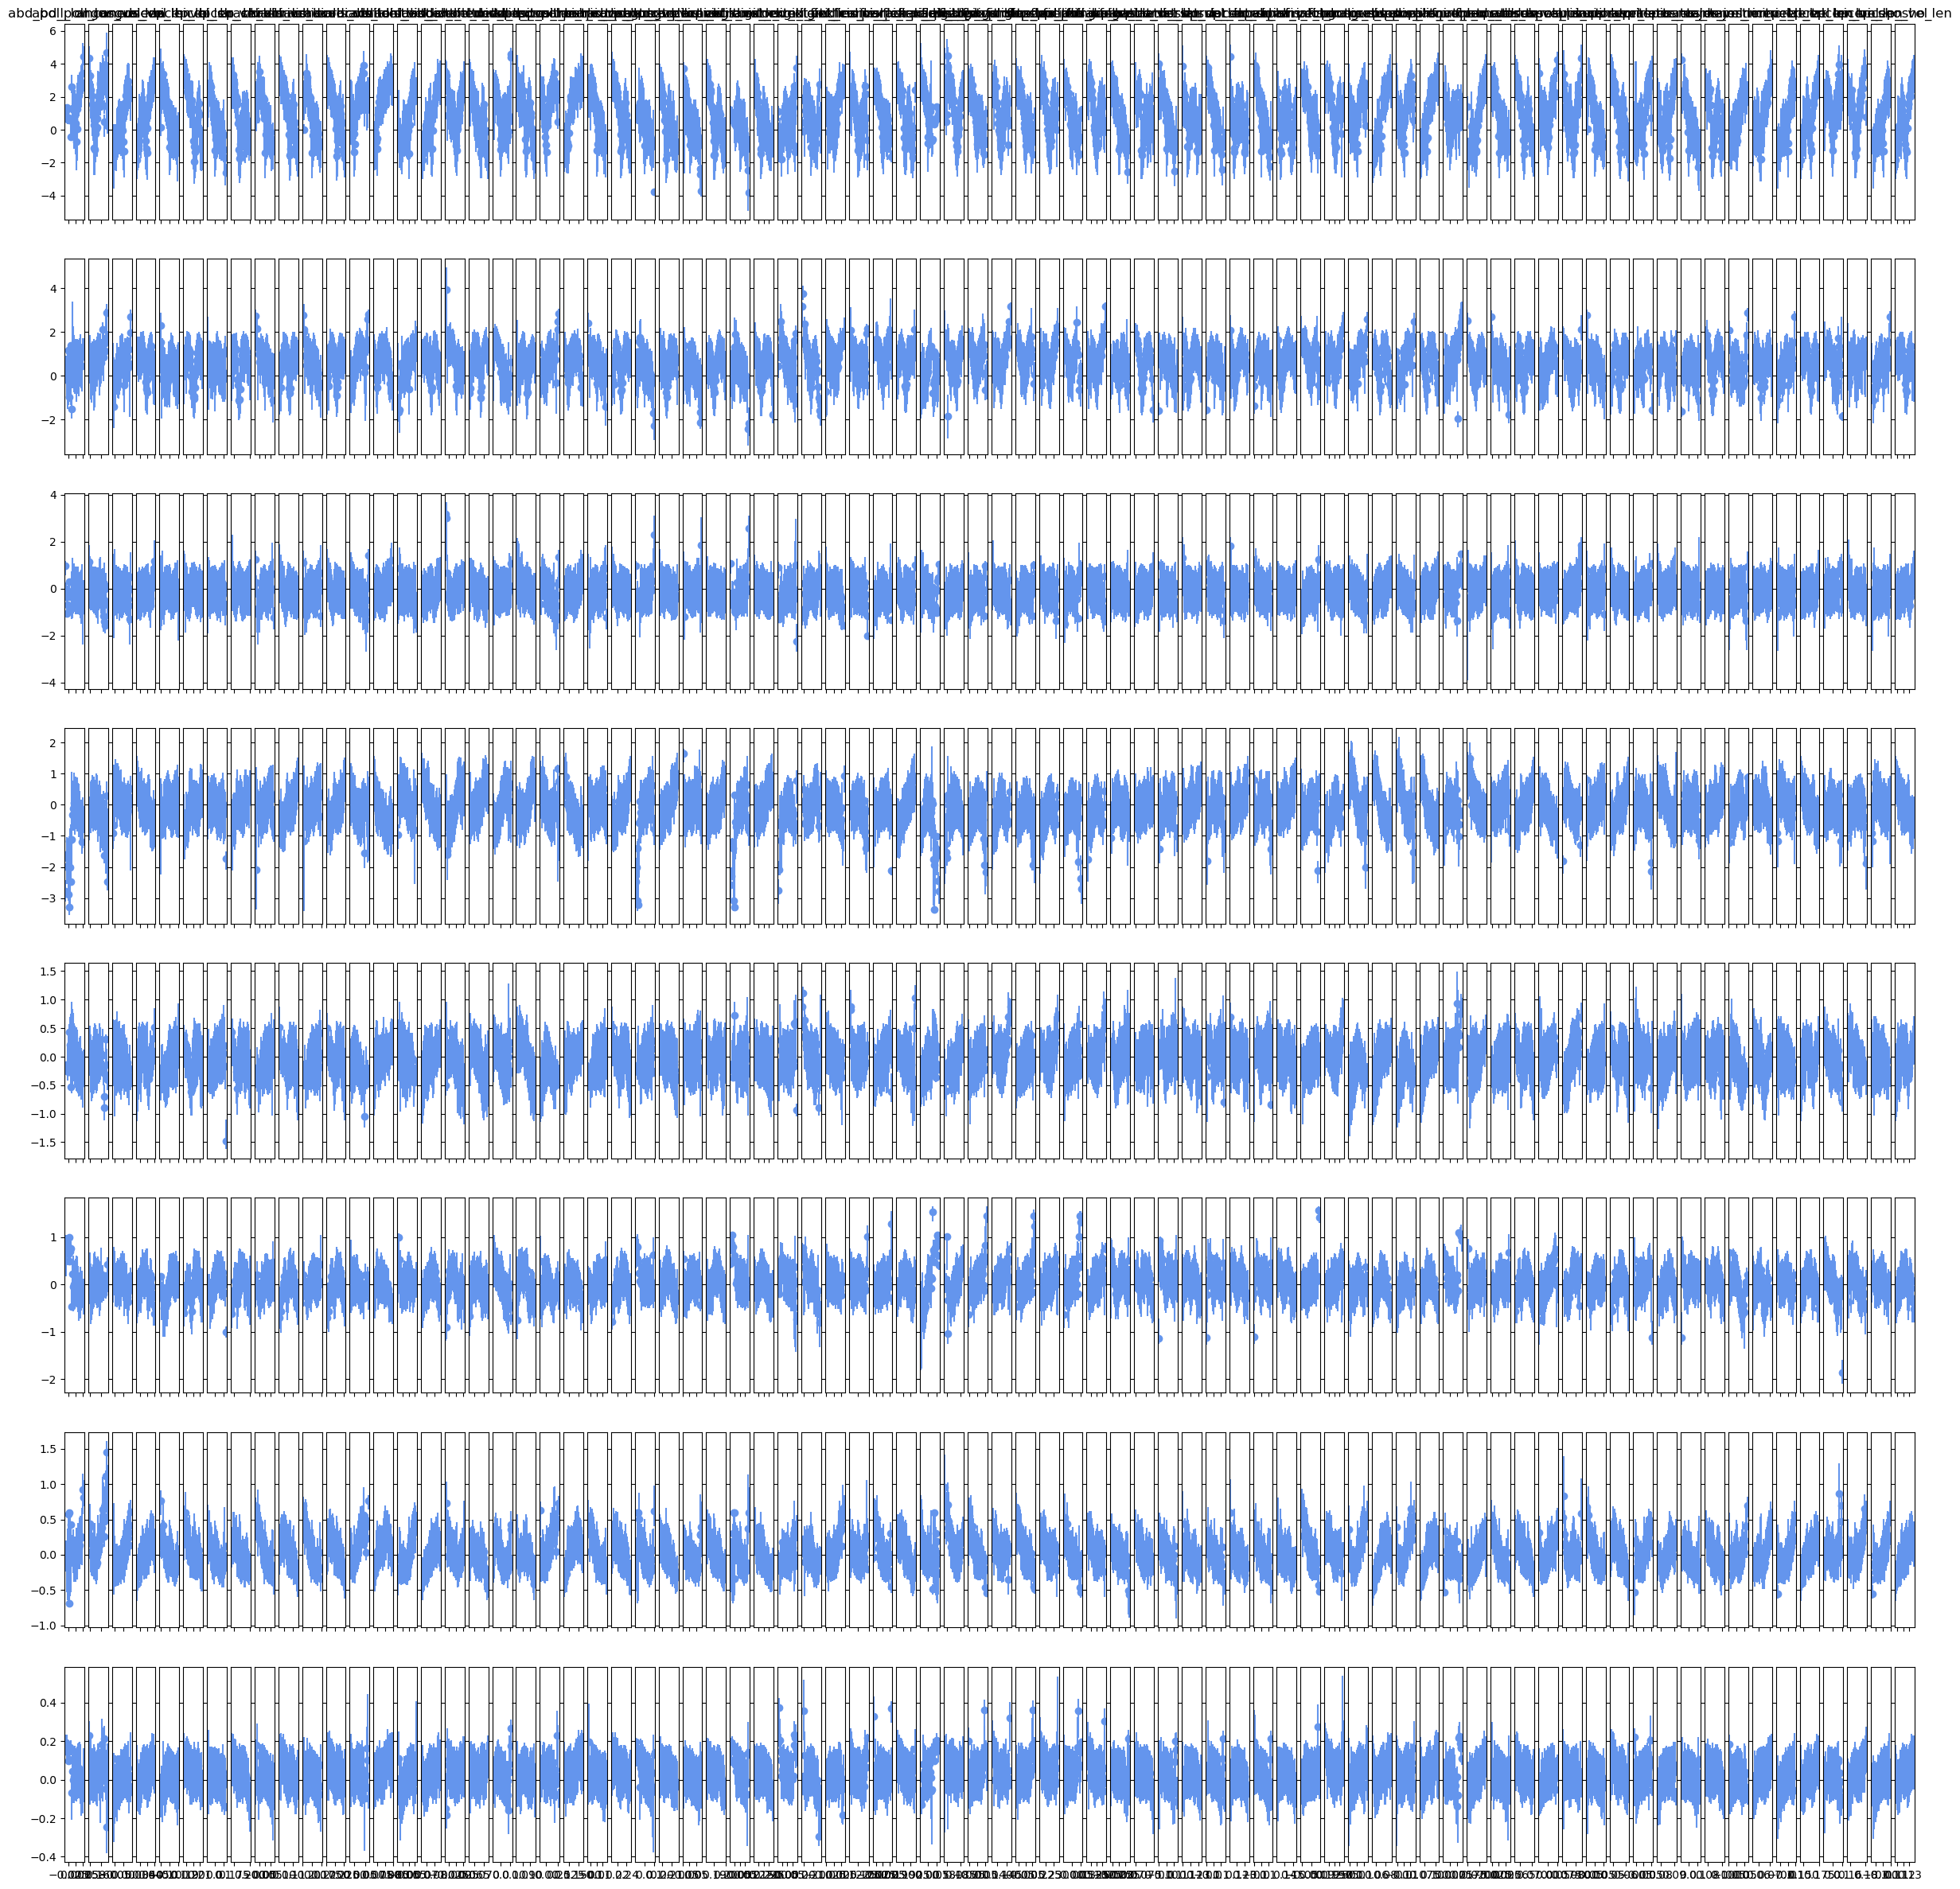

In [ ]:
val = trials_df.copy()
val = val[val.ctr_hold_bump == False]
starts = val.move_onset_time.values
reach_intervals = np.array([starts - 0.1, starts + 0.5]).T

analysis_ = analysis_dict["movement"]
# feature_df = behavior_df.copy()
feature_df = joint_behavior_df
feature_df = muscle_behavior_df


feature_time = feature_df.index.values
fig, ax_list = plt.subplots(
    nrows=context_dim,
    ncols=len(feature_df.columns),
    sharex="col",
    sharey="row",
    figsize=(30, 30),
)
results = {}
for i_feature, feature_name in tqdm(enumerate(feature_df.columns)):
    feature = feature_df[feature_name].values

    ind = np.where(~np.isnan(feature))[0]
    context_binned, bins = analysis_.bin_context_by_feature(
        feature[ind],
        feature_time[ind],
        pca=True,
        valid_intervals=reach_intervals,
        interpolated=True,
    )

    mid = np.array(
        [
            np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
            for b in context_binned
        ]
    )
    lo = np.array(
        [
            (
                np.nanpercentile(b, 25, axis=0)
                if len(b)
                else np.nan * np.zeros(context_dim)
            )
            for b in context_binned
        ]
    )
    hi = np.array(
        [
            (
                np.nanpercentile(b, 75, axis=0)
                if len(b)
                else np.nan * np.zeros(context_dim)
            )
            for b in context_binned
        ]
    )
    results[feature_name] = {
        "bins": bins,
        "mid": mid,
        "lo": lo,
        "hi": hi,
    }

for i_feature, feature_name in enumerate(feature_df.columns):
    bins = results[feature_name]["bins"]
    mid = results[feature_name]["mid"]
    lo = results[feature_name]["lo"]
    hi = results[feature_name]["hi"]

    ax_list[0, i_feature].set_title(f"{feature_name}")
    # for dat, loc in zip(mid, bins):
    for i, a in enumerate(ax_list[:, i_feature]):
        color = "cornflowerblue"
        a.scatter(bins[1:], mid[:, i], c=color)
        for j in range(len(bins) - 1):
            lo_j = lo[j, i]
            hi_j = hi[j, i]
            loc = bins[j + 1]
            a.vlines(loc, lo_j, hi_j, color=color)

    # break

In [125]:
feature_df

{'shoulder_adduction_vel': time
 0.000       -0.085715
 0.001       -0.053650
 0.002       -0.019429
 0.003        0.016822
 0.004        0.054960
               ...    
 2223.444    46.130507
 2223.445    47.053415
 2223.446    47.996712
 2223.447    48.960360
 2223.448    49.944230
 Name: vel, Length: 2223449, dtype: float64,
 'shoulder_adduction_ang': time
 0.000       4.413325
 0.001       4.413488
 0.002       4.413673
 0.003       4.413879
 0.004       4.414106
               ...   
 2223.444   -7.286507
 2223.445   -7.242071
 2223.446   -7.196924
 2223.447   -7.151031
 2223.448   -7.104353
 Name: ang, Length: 2223449, dtype: float64,
 'time': Index([     0.0,    0.001,    0.002,    0.003,    0.004,    0.005,    0.006,
           0.007,    0.008,    0.009,
        ...
        2223.439,  2223.44, 2223.441, 2223.442, 2223.443, 2223.444, 2223.445,
        2223.446, 2223.447, 2223.448],
       dtype='float64', name='time', length=2223449),
 'shoulder_rotation_vel': time
 0.000       

3it [00:09,  3.16s/it]


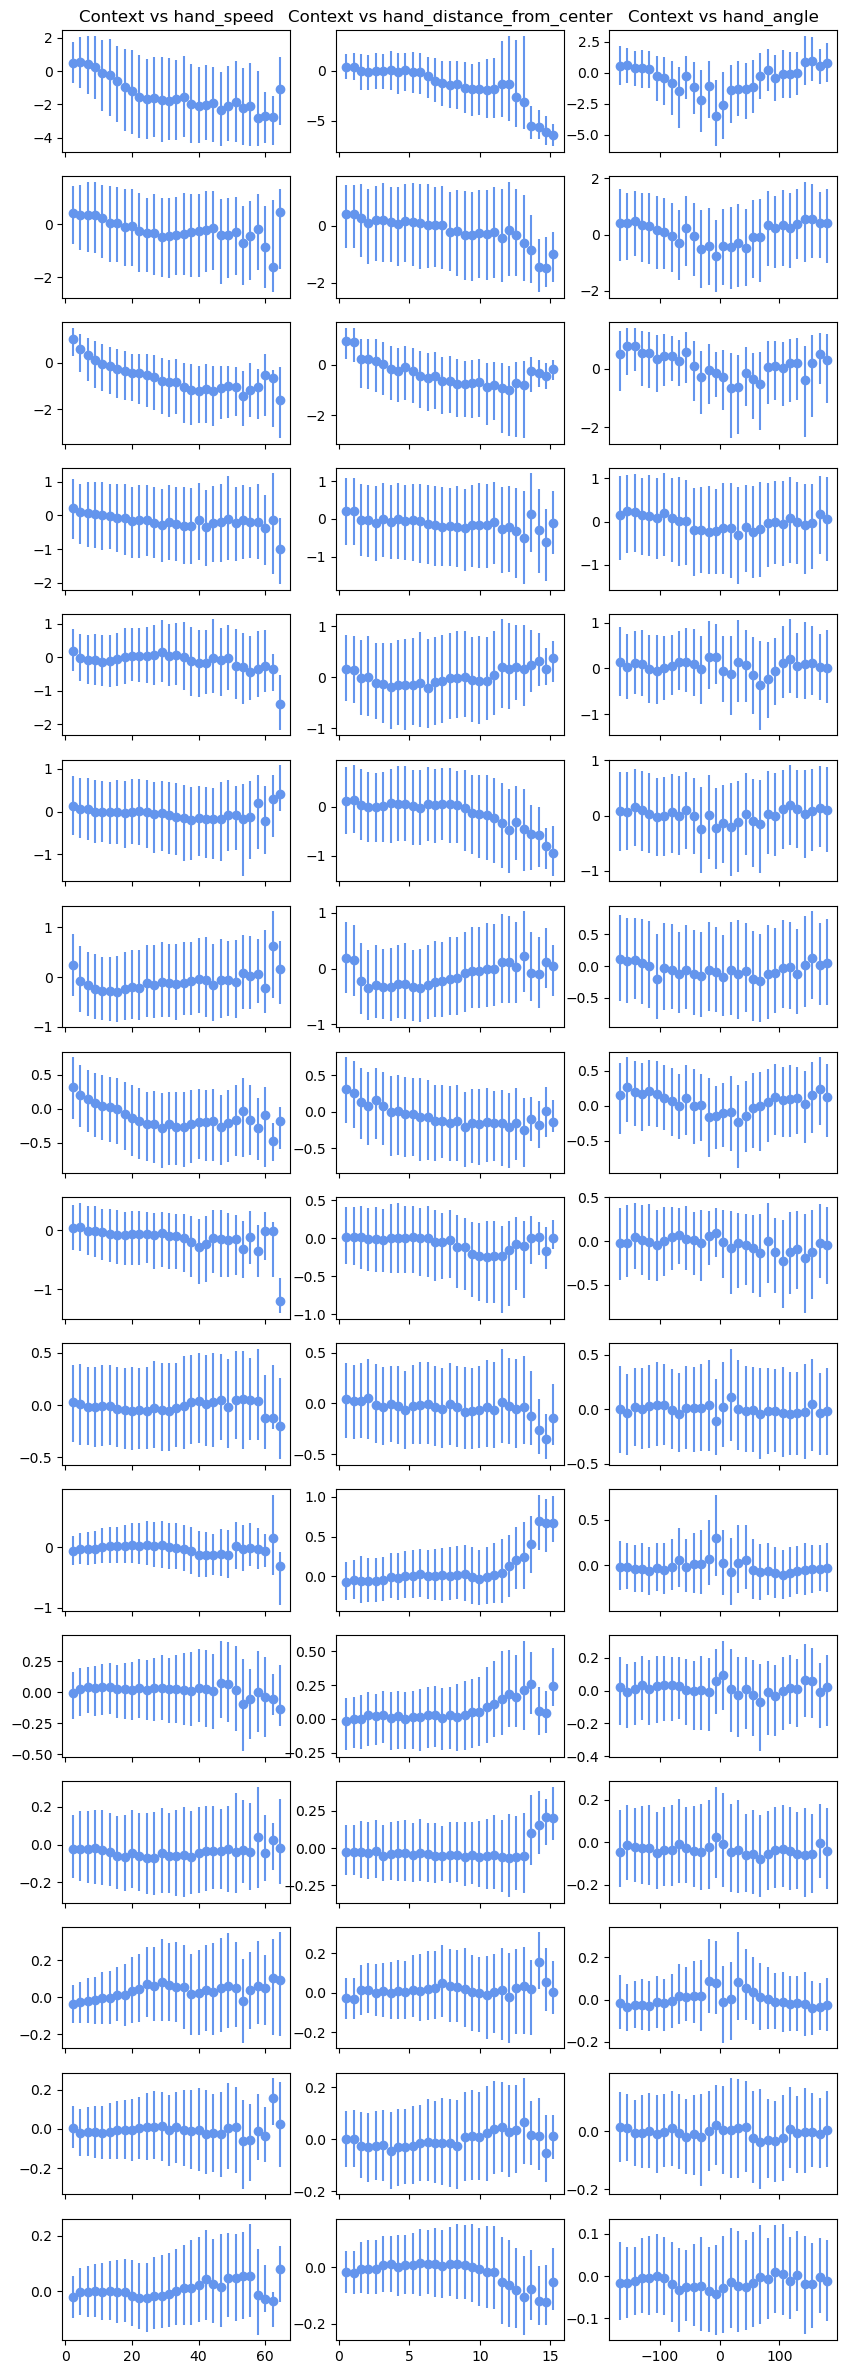

In [ ]:
val = trials_df.copy()
val = val[val.ctr_hold_bump == False]
starts = val.move_onset_time.values
reach_intervals = np.array([starts - 1, starts + 1.5]).T

feature_time = behavior_df.index.values
derived_features = {}
derived_features["hand_speed"] = np.sqrt(
    behavior_df["hand_vel_x"].values ** 2 + behavior_df["hand_vel_y"].values ** 2
)
derived_features["hand_distance_from_center"] = np.sqrt(
    behavior_df["hand_pos_x"].values ** 2 + behavior_df["hand_pos_y"].values ** 2
)
derived_features["hand_angle"] = (
    np.arctan2(behavior_df["hand_pos_y"].values, behavior_df["hand_pos_x"].values)
    * 180
    / np.pi
)

fig, ax_list = plt.subplots(
    nrows=context_dim, ncols=len(derived_features), sharex="col", figsize=(10, 30)
)

results = {}
for i_feature, feature_name in tqdm(enumerate(derived_features)):
    feature = derived_features[feature_name]

    ind = np.where(~np.isnan(feature))[0]
    context_binned, bins = analysis.bin_context_by_feature(
        feature[ind],
        feature_time[ind],
        pca=True,
        valid_intervals=reach_intervals,
        interpolated=True,
    )

    mid = np.array(
        [
            np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
            for b in context_binned
        ]
    )
    lo = np.array(
        [
            (
                np.nanpercentile(b, 25, axis=0)
                if len(b)
                else np.nan * np.zeros(context_dim)
            )
            for b in context_binned
        ]
    )
    hi = np.array(
        [
            (
                np.nanpercentile(b, 75, axis=0)
                if len(b)
                else np.nan * np.zeros(context_dim)
            )
            for b in context_binned
        ]
    )
    results[feature_name] = {
        "bins": bins,
        "mid": mid,
        "lo": lo,
        "hi": hi,
    }

for i_feature, feature_name in enumerate(derived_features):
    bins = results[feature_name]["bins"]
    mid = results[feature_name]["mid"]
    lo = results[feature_name]["lo"]
    hi = results[feature_name]["hi"]

    ax_list[0, i_feature].set_title(f"Context vs {feature_name}")
    # for dat, loc in zip(mid, bins):
    for i, a in enumerate(ax_list[:, i_feature]):
        color = "cornflowerblue"
        a.scatter(bins[1:], mid[:, i], c=color)
        for j in range(len(bins) - 1):
            lo_j = lo[j, i]
            hi_j = hi[j, i]
            loc = bins[j + 1]
            a.vlines(loc, lo_j, hi_j, color=color)

    # break